Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\python312\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step 1 — Accuracy: 0.5092 — Samples: 20


c:\python312\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step 2 — Accuracy: 0.5092 — Samples: 40


c:\python312\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


...

Step 4 — Accuracy: 0.7408 — Samples: 80


c:\python312\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step 5 — Accuracy: 0.7856 — Samples: 100

LLM Epoch 1 Output:
<think>
Okay, so I need to create three new training samples based on the given SST2 dataset examples. First, I'll look at the provided sentences and their sentiments to understand the patterns.

The first sample is "waking coma" labeled as negative. That's pretty brief but clearly negative. Maybe I can make a similar short sentence with a different context. Perhaps something like "awake again" positive?

Next, there's "been this odd, inexplicable and unpleasant" which is also negative. It has more words and describes an unpleasant experience. For my second example, maybe start with a negative emotion but a bit shorter, like "bad day" as a quick way to convey negativity.

Looking at the third sample: "above the rest" positive. This seems to be a comparative statement. I can make one that highlights something positive, such as "best film ever."

Wait, let me think if these are appropriate. Maybe for the first new example, I c

c:\python312\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(



✅ Final Accuracy after LLM samples: 0.8222


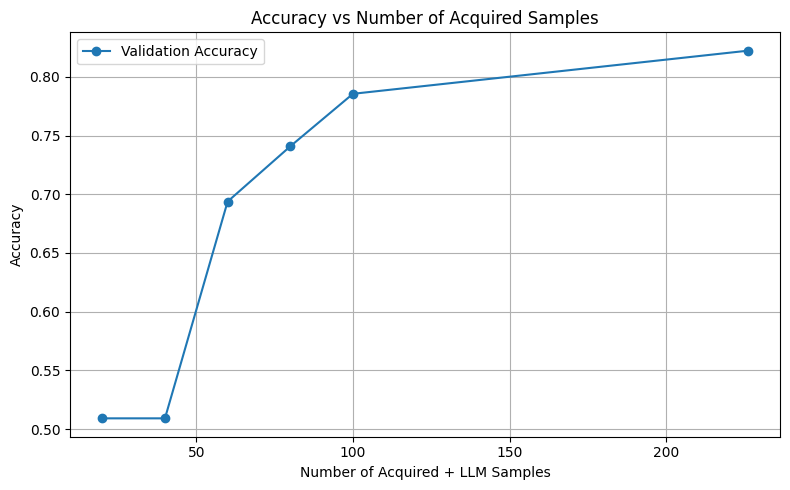

In [2]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, AdamW
from datasets import load_dataset
from sklearn.metrics import accuracy_score
import random
import matplotlib.pyplot as plt
import ollama

# Set random seed
random.seed(42)
torch.manual_seed(42)

# Load SST-2 dataset
dataset = load_dataset("glue", "sst2")
train_data = dataset["train"]
val_data = dataset["validation"]

# Tokenizer & model
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Custom dataset
class SST2Dataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, return_tensors='pt')
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Fine-tune function
def train_model(model, train_dataset, val_dataset, epochs=3, batch_size=16):
    model.train()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    optimizer = AdamW(model.parameters(), lr=5e-5)
    for epoch in range(epochs):
        total_loss = 0
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

    model.eval()
    preds, true_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            true_labels.extend(batch['labels'].cpu().numpy())

    return accuracy_score(true_labels, preds)

# Active Learning Loop
acquired_data = []
initial_indices = random.sample(range(len(train_data)), 20)
acquired_data.extend(initial_indices)
accuracy_scores = []

# First phase: without LLM
steps = 5
samples_per_step = 20

for step in range(steps):
    texts = [train_data[i]['sentence'] for i in acquired_data]
    labels = [train_data[i]['label'] for i in acquired_data]

    train_dataset = SST2Dataset(texts, labels)
    val_dataset = SST2Dataset(val_data['sentence'], val_data['label'])
    acc = train_model(model, train_dataset, val_dataset)
    print(f"Step {step+1} — Accuracy: {acc:.4f} — Samples: {len(acquired_data)}")
    accuracy_scores.append((len(acquired_data), acc))

    # Acquire new samples
    remaining_indices = list(set(range(len(train_data))) - set(acquired_data))
    new_samples = random.sample(remaining_indices, samples_per_step)
    acquired_data.extend(new_samples)

# Now use LLM to generate 60 synthetic samples
def generate_llm_samples(prompt_texts, prompt_labels, n=3):
    prompt = (
        "I will show you 10 training samples from the SST2 sentiment dataset.\n"
        "Each sample has a sentence and a sentiment label (positive or negative).\n"
        "Based on these examples, generate 3 new training samples in the same format.\n"
        "Try to match the sentence style and maintain a similar balance of labels.\n\n"
    )

    for i, (text, label) in enumerate(zip(prompt_texts, prompt_labels)):
        sentiment = "positive" if label == 1 else "negative"
        prompt += f"{i+1}. \"{text}\" — {sentiment}\n"

    prompt += "\nNow generate 3 new examples:"

    response = ollama.chat(
        model='deepseek-r1',
        messages=[{'role': 'user', 'content': prompt}]
    )
    return response['message']['content']

# LLM Sampling
synthetic_texts, synthetic_labels = [], []

for epoch in range(10):  
    indices = random.sample(acquired_data, 10)
    prompt_texts = [train_data[i]['sentence'] for i in indices]
    prompt_labels = [train_data[i]['label'] for i in indices]
    gen_output = generate_llm_samples(prompt_texts, prompt_labels)

    print(f"\nLLM Epoch {epoch+1} Output:\n{gen_output}")

    for line in gen_output.strip().split('\n'):
        try:
            if '"' in line:
                sentence = line.split('"')[1]
                sentiment = line.split('—')[-1].strip().lower()
                label = 1 if "positive" in sentiment else 0
                synthetic_texts.append(sentence)
                synthetic_labels.append(label)
        except Exception as e:
            continue

# Add LLM generated data to train set and retrain
texts = [train_data[i]['sentence'] for i in acquired_data] + synthetic_texts
labels = [train_data[i]['label'] for i in acquired_data] + synthetic_labels

train_dataset = SST2Dataset(texts, labels)
val_dataset = SST2Dataset(val_data['sentence'], val_data['label'])
final_acc = train_model(model, train_dataset, val_dataset)

print(f"\n✅ Final Accuracy after LLM samples: {final_acc:.4f}")
accuracy_scores.append((len(acquired_data) + len(synthetic_texts), final_acc))

# Plot
x_vals, y_vals = zip(*accuracy_scores)
plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, marker='o', label="Validation Accuracy")
plt.xlabel("Number of Acquired + LLM Samples")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Acquired Samples")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_plot.png")
plt.show()
